# Task Verification

Visualize trial structure for Task 1 (unisensory block-switching) and Task 2 (multisensory implicit context) to verify correct generation.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from src.tasks import Task1Session, Task2Session

sns.set_style('whitegrid')
sns.set_context('notebook')

## Task 1: Unisensory Block-Switching

In [2]:
session1 = Task1Session(n_trials=300, block_size=50, n_switches=3, seed=42)
print(f'Task 1: {len(session1)} trials generated')

Task 1: 300 trials generated


### Trial Timeline / Raster

Shows visual direction, auditory direction, context, and correct answer across all trials. Vertical dashed lines mark context switch points.

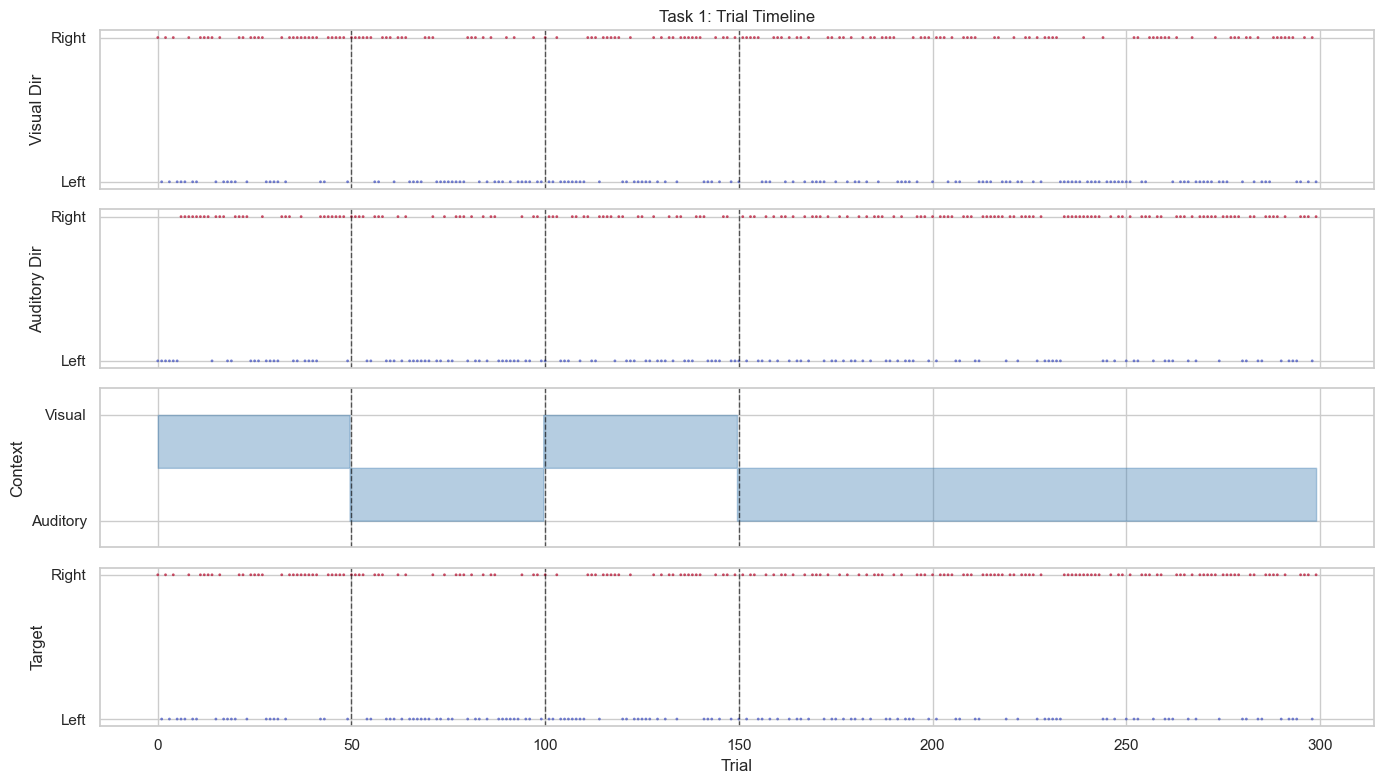

Context switches at trials: [50, 100, 150]


In [3]:
# Extract trial-level data
n = len(session1)
trial_idx = np.arange(n)

vis_dirs = []
aud_dirs = []
contexts = []
targets = []

for trial in session1.trials:
    stim = trial['inputs'][5]  # stimulus epoch
    # Visual direction: sin(theta) component
    # sin(0)=0 -> left, sin(90)=1 -> right
    vis_dirs.append(1 if stim[1].item() > 0.5 else -1)
    # Auditory direction: first component
    # -1 -> left, 1 -> right
    aud_dirs.append(1 if stim[2].item() > 0 else -1)
    # Context: 1 = visual, -1 = auditory
    contexts.append(1 if trial['metadata']['context'] == 'visual' else -1)
    # Target: 0 = left, 1 = right -> map to -1, 1
    targets.append(1 if trial['target'] == 1 else -1)

vis_dirs = np.array(vis_dirs)
aud_dirs = np.array(aud_dirs)
contexts = np.array(contexts)
targets = np.array(targets)

# Find switch points
switch_points = [i for i in range(1, n) if contexts[i] != contexts[i-1]]

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

# Visual direction
axes[0].scatter(trial_idx, vis_dirs, c=vis_dirs, cmap='coolwarm',
                s=4, alpha=0.7, edgecolors='none')
axes[0].set_ylabel('Visual Dir')
axes[0].set_yticks([-1, 1])
axes[0].set_yticklabels(['Left', 'Right'])
axes[0].set_title('Task 1: Trial Timeline')

# Auditory direction
axes[1].scatter(trial_idx, aud_dirs, c=aud_dirs, cmap='coolwarm',
                s=4, alpha=0.7, edgecolors='none')
axes[1].set_ylabel('Auditory Dir')
axes[1].set_yticks([-1, 1])
axes[1].set_yticklabels(['Left', 'Right'])

# Context
axes[2].fill_between(trial_idx, 0, contexts, alpha=0.4,
                     step='mid', color='steelblue')
axes[2].set_ylabel('Context')
axes[2].set_yticks([-1, 1])
axes[2].set_yticklabels(['Auditory', 'Visual'])
axes[2].set_ylim(-1.5, 1.5)

# Correct answer
axes[3].scatter(trial_idx, targets, c=targets, cmap='coolwarm',
                s=4, alpha=0.7, edgecolors='none')
axes[3].set_ylabel('Target')
axes[3].set_yticks([-1, 1])
axes[3].set_yticklabels(['Left', 'Right'])
axes[3].set_xlabel('Trial')

# Mark switch points
for ax in axes:
    for sp in switch_points:
        ax.axvline(sp, color='black', linestyle='--', alpha=0.6, linewidth=1)

plt.tight_layout()
plt.savefig('../figures/task1_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Context switches at trials: {switch_points}')

### Context-Invariant vs Context-Dependent Input Channels

Shows which input dimensions change with context (context cue) and which maintain the same encoding regardless of context (stimulus channels). This helps understand what the network needs to learn.

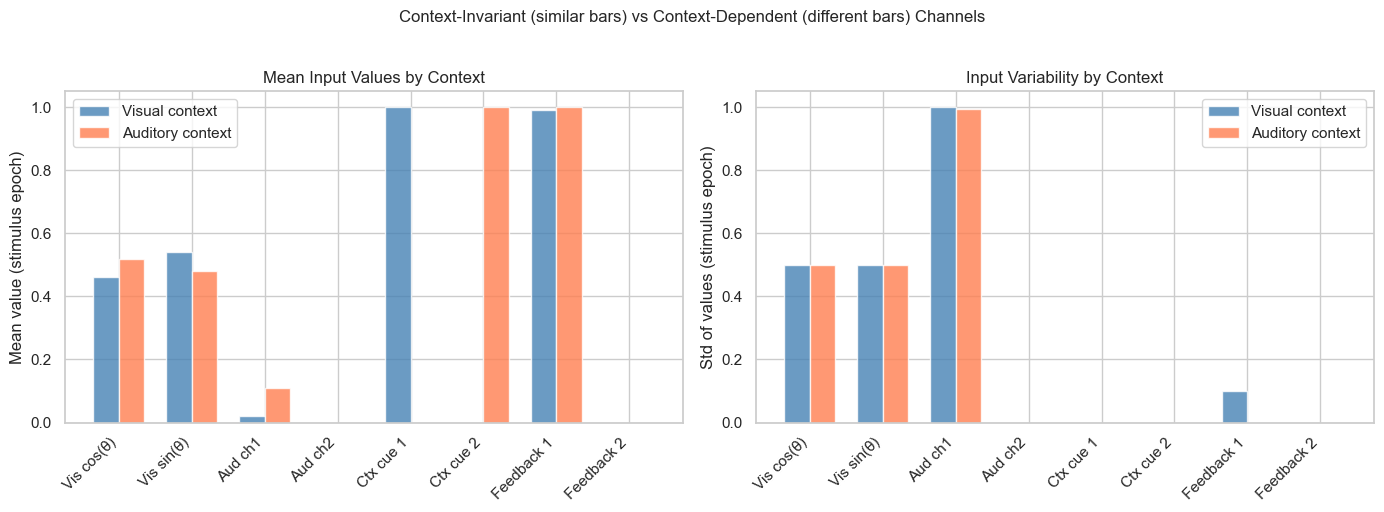

In [5]:
# For each input channel, compute mean absolute value in each context
channel_names = ['Vis cos(θ)', 'Vis sin(θ)', 'Aud ch1', 'Aud ch2',
                 'Ctx cue 1', 'Ctx cue 2', 'Feedback 1', 'Feedback 2']

vis_ctx_vals = []  # mean stimulus-epoch values during visual context
aud_ctx_vals = []  # mean stimulus-epoch values during auditory context

vis_ctx_inputs = []
aud_ctx_inputs = []

for trial in session1.trials:
    stim_mean = trial['inputs'][5:15].mean(dim=0).numpy()  # avg over stimulus epoch
    if trial['metadata']['context'] == 'visual':
        vis_ctx_inputs.append(stim_mean)
    else:
        aud_ctx_inputs.append(stim_mean)

vis_ctx_mean = np.mean(vis_ctx_inputs, axis=0)
aud_ctx_mean = np.mean(aud_ctx_inputs, axis=0)
vis_ctx_std = np.std(vis_ctx_inputs, axis=0)
aud_ctx_std = np.std(aud_ctx_inputs, axis=0)

x = np.arange(8)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean values per context
axes[0].bar(x - width/2, vis_ctx_mean, width, label='Visual context',
            color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, aud_ctx_mean, width, label='Auditory context',
            color='coral', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(channel_names, rotation=45, ha='right')
axes[0].set_ylabel('Mean value (stimulus epoch)')
axes[0].set_title('Mean Input Values by Context')
axes[0].legend()
axes[0].axhline(0, color='gray', linewidth=0.5)

# Variability per context (std)
axes[1].bar(x - width/2, vis_ctx_std, width, label='Visual context',
            color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, aud_ctx_std, width, label='Auditory context',
            color='coral', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(channel_names, rotation=45, ha='right')
axes[1].set_ylabel('Std of values (stimulus epoch)')
axes[1].set_title('Input Variability by Context')
axes[1].legend()

plt.suptitle('Context-Invariant (similar bars) vs Context-Dependent (different bars) Channels',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('../figures/task1_context_channels.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 2: Multisensory Implicit Context

In [6]:
session2 = Task2Session(n_trials=300, block_size=50, n_switches=3, seed=42)
print(f'Task 2: {len(session2)} trials generated')

n_cong = sum(1 for t in session2.trials if t['metadata']['is_congruent'])
n_incong = len(session2) - n_cong
print(f'Congruent: {n_cong}, Incongruent: {n_incong}, '
      f'Ratio: {n_cong/len(session2):.2f}')

Task 2: 300 trials generated
Congruent: 150, Incongruent: 150, Ratio: 0.50


### Trial Timeline (Color-Coded by Congruence)

Green = congruent (both cues agree), Red = incongruent (cues conflict). Dashed lines mark context switches.

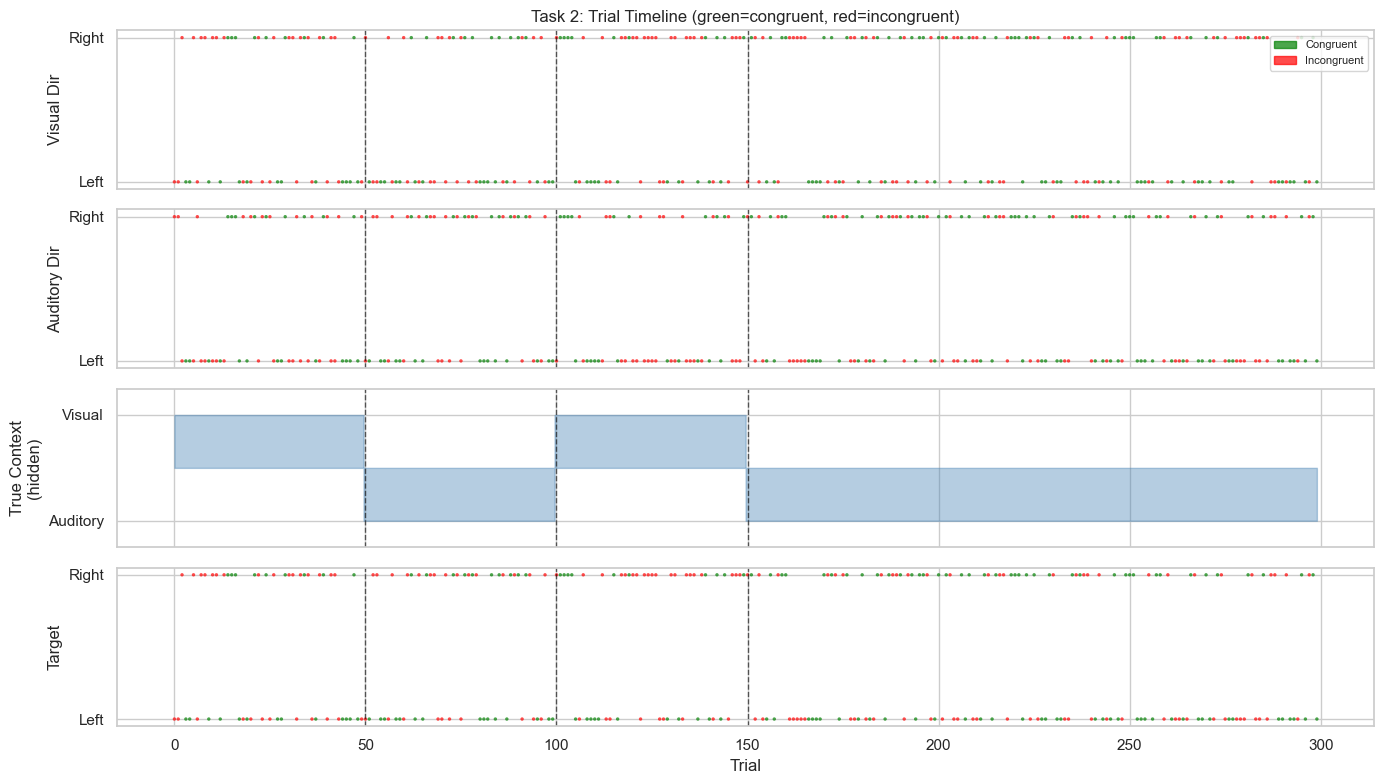

Context switches at trials: [50, 100, 150]


In [7]:
n2 = len(session2)
trial_idx2 = np.arange(n2)

vis_dirs2 = []
aud_dirs2 = []
contexts2 = []
targets2 = []
congruent2 = []

for trial in session2.trials:
    meta = trial['metadata']
    vis_dirs2.append(1 if meta['visual_direction'] == 'right' else -1)
    aud_dirs2.append(1 if meta['auditory_direction'] == 'right' else -1)
    contexts2.append(1 if meta['context'] == 'visual' else -1)
    targets2.append(1 if trial['target'] == 1 else -1)
    congruent2.append(meta['is_congruent'])

vis_dirs2 = np.array(vis_dirs2)
aud_dirs2 = np.array(aud_dirs2)
contexts2 = np.array(contexts2)
targets2 = np.array(targets2)
congruent2 = np.array(congruent2)

switch_points2 = [i for i in range(1, n2) if contexts2[i] != contexts2[i-1]]
colors2 = ['green' if c else 'red' for c in congruent2]

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

# Visual direction
axes[0].scatter(trial_idx2, vis_dirs2, c=colors2, s=6, alpha=0.7, edgecolors='none')
axes[0].set_ylabel('Visual Dir')
axes[0].set_yticks([-1, 1])
axes[0].set_yticklabels(['Left', 'Right'])
axes[0].set_title('Task 2: Trial Timeline (green=congruent, red=incongruent)')

# Auditory direction
axes[1].scatter(trial_idx2, aud_dirs2, c=colors2, s=6, alpha=0.7, edgecolors='none')
axes[1].set_ylabel('Auditory Dir')
axes[1].set_yticks([-1, 1])
axes[1].set_yticklabels(['Left', 'Right'])

# Context (hidden from network, shown here for verification)
axes[2].fill_between(trial_idx2, 0, contexts2, alpha=0.4,
                     step='mid', color='steelblue')
axes[2].set_ylabel('True Context\n(hidden)')
axes[2].set_yticks([-1, 1])
axes[2].set_yticklabels(['Auditory', 'Visual'])
axes[2].set_ylim(-1.5, 1.5)

# Correct answer
axes[3].scatter(trial_idx2, targets2, c=colors2, s=6, alpha=0.7, edgecolors='none')
axes[3].set_ylabel('Target')
axes[3].set_yticks([-1, 1])
axes[3].set_yticklabels(['Left', 'Right'])
axes[3].set_xlabel('Trial')

# Mark switch points
for ax in axes:
    for sp in switch_points2:
        ax.axvline(sp, color='black', linestyle='--', alpha=0.6, linewidth=1)

# Legend
green_patch = mpatches.Patch(color='green', alpha=0.7, label='Congruent')
red_patch = mpatches.Patch(color='red', alpha=0.7, label='Incongruent')
axes[0].legend(handles=[green_patch, red_patch], loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/task2_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Context switches at trials: {switch_points2}')

### "Follow Visual" vs "Follow Auditory" Accuracy

Sliding-window accuracy if the network always followed one modality. These diverge on incongruent trials depending on which modality is currently relevant.

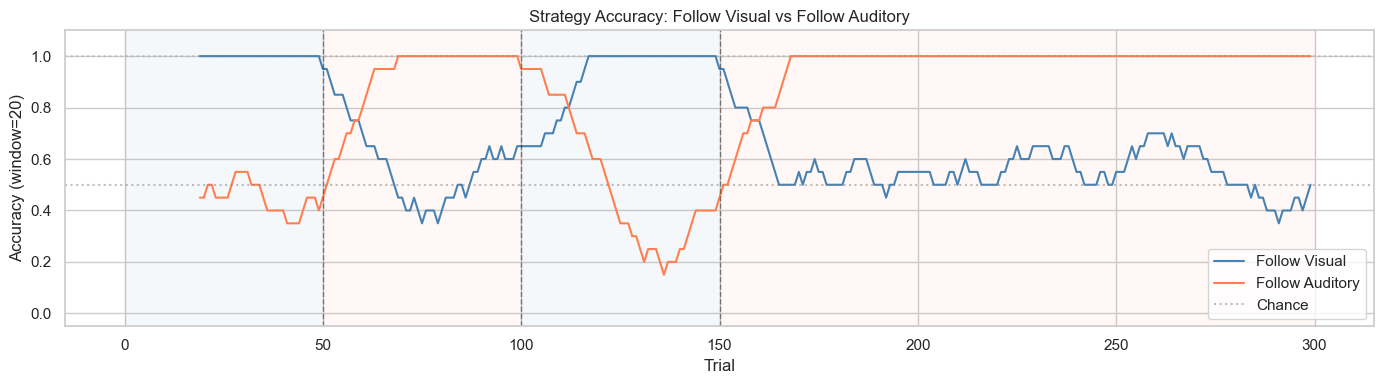

In [8]:
# Compute per-trial accuracy for "follow visual" and "follow auditory" strategies
follow_vis_correct = []
follow_aud_correct = []

for trial in session2.trials:
    meta = trial['metadata']
    target = trial['target']
    vis_target = 0 if meta['visual_direction'] == 'left' else 1
    aud_target = 0 if meta['auditory_direction'] == 'left' else 1
    follow_vis_correct.append(int(vis_target == target))
    follow_aud_correct.append(int(aud_target == target))

follow_vis_correct = np.array(follow_vis_correct)
follow_aud_correct = np.array(follow_aud_correct)

# Sliding window accuracy
window = 20
vis_acc = np.convolve(follow_vis_correct, np.ones(window)/window, mode='valid')
aud_acc = np.convolve(follow_aud_correct, np.ones(window)/window, mode='valid')
x_acc = np.arange(window - 1, n2)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(x_acc, vis_acc, color='steelblue', linewidth=1.5, label='Follow Visual')
ax.plot(x_acc, aud_acc, color='coral', linewidth=1.5, label='Follow Auditory')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.3)

for sp in switch_points2:
    ax.axvline(sp, color='black', linestyle='--', alpha=0.4, linewidth=1)

# Shade context blocks
block_starts = [0] + switch_points2 + [n2]
for i in range(len(block_starts) - 1):
    ctx = session2.trials[block_starts[i]]['metadata']['context']
    color = 'steelblue' if ctx == 'visual' else 'coral'
    ax.axvspan(block_starts[i], block_starts[i+1], alpha=0.05, color=color)

ax.set_xlabel('Trial')
ax.set_ylabel(f'Accuracy (window={window})')
ax.set_title('Strategy Accuracy: Follow Visual vs Follow Auditory')
ax.legend(loc='lower right')
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.savefig('../figures/task2_strategy_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

### Congruent vs Incongruent Trial Counts

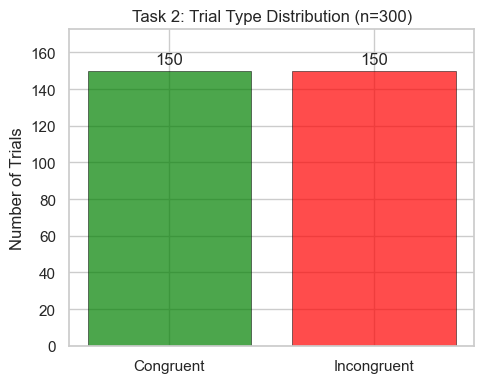

Congruent: 150 (50.0%)
Incongruent: 150 (50.0%)


In [9]:
n_cong = sum(1 for t in session2.trials if t['metadata']['is_congruent'])
n_incong = len(session2) - n_cong

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Congruent', 'Incongruent'], [n_cong, n_incong],
              color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=0.5)

# Add count labels
for bar, count in zip(bars, [n_cong, n_incong]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(count), ha='center', va='bottom', fontsize=12)

ax.set_ylabel('Number of Trials')
ax.set_title(f'Task 2: Trial Type Distribution (n={len(session2)})')
ax.set_ylim(0, max(n_cong, n_incong) * 1.15)

plt.tight_layout()
plt.savefig('../figures/task2_trial_counts.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Congruent: {n_cong} ({n_cong/len(session2)*100:.1f}%)')
print(f'Incongruent: {n_incong} ({n_incong/len(session2)*100:.1f}%)')